### Problem Understanding

#### Business Context and Objective

*The bank conducts periodic marketing campaigns to promote its term deposit products by contacting potential clients via phone calls. However, many of these calls do not result in successful subscriptions, leading to significant time and resource wastage.<br>
The primary business objective is to identify clients who are most likely to subscribe to a term deposit based on their demographic, financial, and previous campaign interaction details. By targeting these promising clients, the marketing team can:*
- *Improve campaign efficiency and return on investment (ROI)*
- *Reduce operational costs from unsuccessful calls*
- *Enhance customer experience by personalizing marketing efforts*

#### Machine Learning Formulation

*This problem can be framed as a supervised binary classification task.*

***Input (Features):*** *Client attributes such as age, job type, marital status, education, balance, contact type, previous outcome, and campaign-related features (number of contacts, days since last contact, etc.).*

***Target (Label):*** *Whether the client subscribed to a term deposit (Yes = 1, No = 0).*

***Machine Learning Goal:*** *Train a model that learns patterns from historical campaign data to predict the likelihood of subscription for new or future clients.*

*Possible algorithms include Logistic Regression, Random Forests, Gradient Boosting, or even Neural Networks depending on performance and interpretability needs.*

#### Success Metrics

*Since the dataset is often imbalanced (more “No” than “Yes” outcomes), accuracy alone is not a good indicator of model performance. Instead, the following metrics are more appropriate:*

***Precision:*** *Measures how many predicted “Yes” outcomes were actually “Yes” (useful when cost of false positives is high).*

***Recall (Sensitivity):*** *Measures how many actual “Yes” clients were correctly identified (important to minimize missed opportunities).*

***F1-score:*** *Harmonic mean of precision and recall to balance both.*

***ROC-AUC score:*** *Evaluates model’s ability to rank positive over negative cases regardless of threshold.*

*From a business standpoint, maximizing recall (to capture as many potential subscribers as possible) while maintaining a reasonable precision ensures cost-effective targeting.*

### Data Understanding & EDA

#### Load the dataset

In [1]:
#  Core 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time, cloudpickle, os
warnings.filterwarnings('ignore')

#  Stats 
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import scipy.stats as stats

#  Sklearn: Preprocessing 
from sklearn.base import clone
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

#  Sklearn: Model Selection 
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV

#  Sklearn: Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#  Sklearn: Metrics 
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

#  Sklearn: Feature Selection 
from sklearn.feature_selection import mutual_info_classif

#  Statsmodels 
from statsmodels.stats.outliers_influence import variance_inflation_factor

#  Imbalanced Learn 
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

#  Boosting 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

#  Counter 
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter

ACCENT  = "#38bdf8"   # sky-blue
ACCENT2 = "#f472b6"   # pink
ACCENT3 = "#34d399"   # emerald
ACCENT4 = "#fb923c"   # orange
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, "#a78bfa", "#fbbf24"]

In [ ]:
df = pd.read_csv('../datasets/raw/bank-full.csv', sep=';')
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head()

Dataset shape : 45,211 rows × 17 columns
Memory usage  : 27.00 MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


##### Key Observations:
1. The dataset has 45,211 records and 17 columns, with no missing values in any column.
2. There are 7 numerical variables and 10 categorical variables, so both preprocessing and encoding will be important before modeling.
3. The target column y is categorical, which confirms this is a classification problem.

| Name        | Role    | Type        | Units | Description                                                                                                                                                                                                                                                                                                                                                                                                        | Missing Values |
| ----------- | ------- | ----------- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------- |
| age         | feature | integer     |       |                                                                                                                                                                                                                                                                                                                                                                                                                    | No             |
| job         | feature | categorical |       | type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')                                                                                                                                                                                                                                       | No             |
| marital     | feature | categorical |       | marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)                                                                                                                                                                                                                                                                                                  | No             |
| education   | feature | categorical |       | (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')                                                                                                                                                                                                                                                                                     | No             |
| default     | feature | binary      |       | has credit in default?                                                                                                                                                                                                                                                                                                                                                                                             | No             |
| balance     | feature | integer     | euros | average yearly balance                                                                                                                                                                                                                                                                                                                                                                                             | No             |
| housing     | feature | binary      |       | has housing loan?                                                                                                                                                                                                                                                                                                                                                                                                  | No             |
| loan        | feature | binary      |       | has personal loan?                                                                                                                                                                                                                                                                                                                                                                                                 | No             |
| contact     | feature | categorical |       | contact communication type (categorical: 'cellular','telephone')                                                                                                                                                                                                                                                                                                                                                   | Yes            |
| day | feature | date        |       | last contact day of the week                                                                                                                                                                                                                                                                                                                                                                                       | No             |
| month       | feature | date        |       | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')                                                                                                                                                                                                                                                                                                                                   | No             |
| duration    | feature | integer     |       | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. | No             |
| campaign    | feature | integer     |       | number of contacts performed during this campaign and for this client (numeric, includes last contact)                                                                                                                                                                                                                                                                                                             | No             |
| pdays       | feature | integer     |       | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)                                                                                                                                                                                                                                                                 | Yes            |
| previous    | feature | integer     |       | number of contacts performed before this campaign and for this client                                                                                                                                                                                                                                                                                                                                              | No             |
| poutcome    | feature | categorical |       | outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')                                                                                                                                                                                                                                                                                                                        | Yes            |
| y           | target  | binary      |       | has the client subscribed a term deposit?                                                                                                                                                                                                                                                                                                                                                                          | No             |

#### Data observations

In [3]:
df = df.rename(columns={
    'default': 'has_credit', 
    'housing':'housing_loan', 
    'loan':'personal_loan', 
    'campaign':'total_calls', 
    'previous':'p_total_calls', 
    'poutcome':'p_y'
})

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            45211 non-null  int64 
 1   job            45211 non-null  object
 2   marital        45211 non-null  object
 3   education      45211 non-null  object
 4   has_credit     45211 non-null  object
 5   balance        45211 non-null  int64 
 6   housing_loan   45211 non-null  object
 7   personal_loan  45211 non-null  object
 8   contact        45211 non-null  object
 9   day            45211 non-null  int64 
 10  month          45211 non-null  object
 11  duration       45211 non-null  int64 
 12  total_calls    45211 non-null  int64 
 13  pdays          45211 non-null  int64 
 14  p_total_calls  45211 non-null  int64 
 15  p_y            45211 non-null  object
 16  y              45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,total_calls,pdays,p_total_calls
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


##### Numerical Feature Insights
1. Age ranges from 18 to 95, with an average of about 41 years. Most customers are concentrated in the 33–48 age range.
2. Balance shows a very wide spread, from -8,019 to 102,127, indicating the presence of extreme outliers and possibly financially diverse customers.
3. Day ranges from 1 to 31, suggesting it is a calendar-day feature rather than a duration-based behavioral variable.
4. Duration has a large variation, from 0 to 4,918 seconds, with a mean of about 258 seconds. This feature may be highly informative, but it should be treated carefully because it can introduce data leakage if used incorrectly in a real total_calls prediction setting.
5. Total_calls ranges from 1 to 63, with most values around 1 to 3, meaning most clients were contacted only a few times.
6. Pdays has a median of -1, which usually means the client was not previously contacted in a prior total_calls.
7. Previous Total Calls is heavily skewed toward 0, showing that most clients had no previous contacts before the current total_calls.

In [5]:
# Categorical columns values
cat_cols = ['job', 'marital', 'education', 'contact', 'has_credit', 'housing_loan', 'personal_loan', 'month', 'p_y', 'y']
num_cols = ['age', 'balance', 'duration', 'day', 'total_calls', 'pdays', 'p_total_calls']
for i in cat_cols:
    print(f'{i.capitalize()}: {df[i].unique()}')
    print()

Job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

Marital: ['married' 'single' 'divorced']

Education: ['tertiary' 'secondary' 'unknown' 'primary']

Contact: ['unknown' 'cellular' 'telephone']

Has_credit: ['no' 'yes']

Housing_loan: ['yes' 'no']

Personal_loan: ['no' 'yes']

Month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

P_y: ['unknown' 'failure' 'other' 'success']

Y: ['no' 'yes']



##### Important Data Quality / Distribution Notes
1. Several numerical features are right-skewed and likely contain outliers, especially balance, duration, total_calls, pdays, and p_total_calls.
2. The negative value in balance is valid and indicates some customers may have overdraft or negative account balances.
3. The negative value -1 in pdays is important because it likely represents a special category: not previously contacted.
4. Since previous is mostly 0, and pdays is often -1, the dataset suggests that most customers are being reached for the first time.

#### Data Inconsistancies

In [6]:
df["pdays"] = df["pdays"].replace(-1, 0)
df['job']=np.where(df['job']=='admin.', 'admin', df['job'])
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [7]:
bi_cols = ['has_credit', 'housing_loan', 'personal_loan', 'y']

for i in cat_cols:
    df[i] = df[i].astype('category')
    
for col in bi_cols:
    df[col] = df[col].map({'no': 0, 'yes': 1}).astype('int8')
    
month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
df['month'] = df['month'].map(month_map).astype('int64')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            45211 non-null  int64   
 1   job            45211 non-null  category
 2   marital        45211 non-null  category
 3   education      45211 non-null  category
 4   has_credit     45211 non-null  int8    
 5   balance        45211 non-null  int64   
 6   housing_loan   45211 non-null  int8    
 7   personal_loan  45211 non-null  int8    
 8   contact        45211 non-null  category
 9   day            45211 non-null  int64   
 10  month          45211 non-null  int64   
 11  duration       45211 non-null  int64   
 12  total_calls    45211 non-null  int64   
 13  pdays          45211 non-null  int64   
 14  p_total_calls  45211 non-null  int64   
 15  p_y            45211 non-null  category
 16  y              45211 non-null  int8    
dtypes: category(5), int64(8), int8(

#### Target Distribution

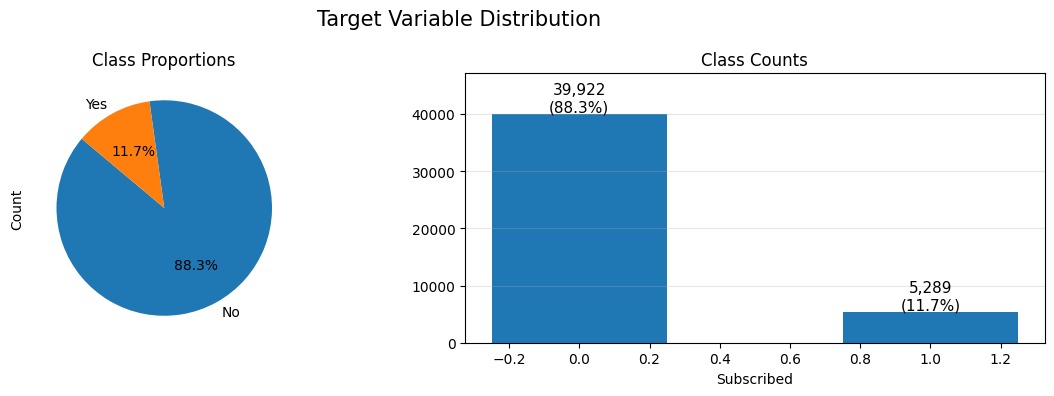

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Target Variable Distribution", fontsize=15)

counts = df["y"].value_counts()

# Pie chart
axes[0].pie(counts.values, autopct="%1.1f%%", startangle=140, labels=['No', 'Yes'])
axes[0].set_title("Class Proportions")

# Bar chart
axes[1].bar(counts.index, counts.values, width=0.5, linewidth=1.5)
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v + 500, f"{v:,}\n({100*v/len(df):.1f}%)", ha="center", fontsize=11)
axes[1].set_title("Class Counts")
axes[1].set_xlabel("Subscribed"); axes[0].set_ylabel("Count")
axes[1].set_ylim(0, counts.max() * 1.18)
axes[1].grid(axis="y", alpha=0.3)
plt.savefig("Target Variable Distribution.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

##### Target Distribution Insights

88% No vs 12% Yes -> Severe class imbalance

Problem: Accuracy = 88% is meaningless (dummy classifier baseline)

Business Impact: Model must catch rare 12% high-value subscribers

Solution: Use SMOTE techniques for balancing the data, F1-score, Precision-Recall curves, AUC evaluation

#### Numerical Feature Distributions by Target

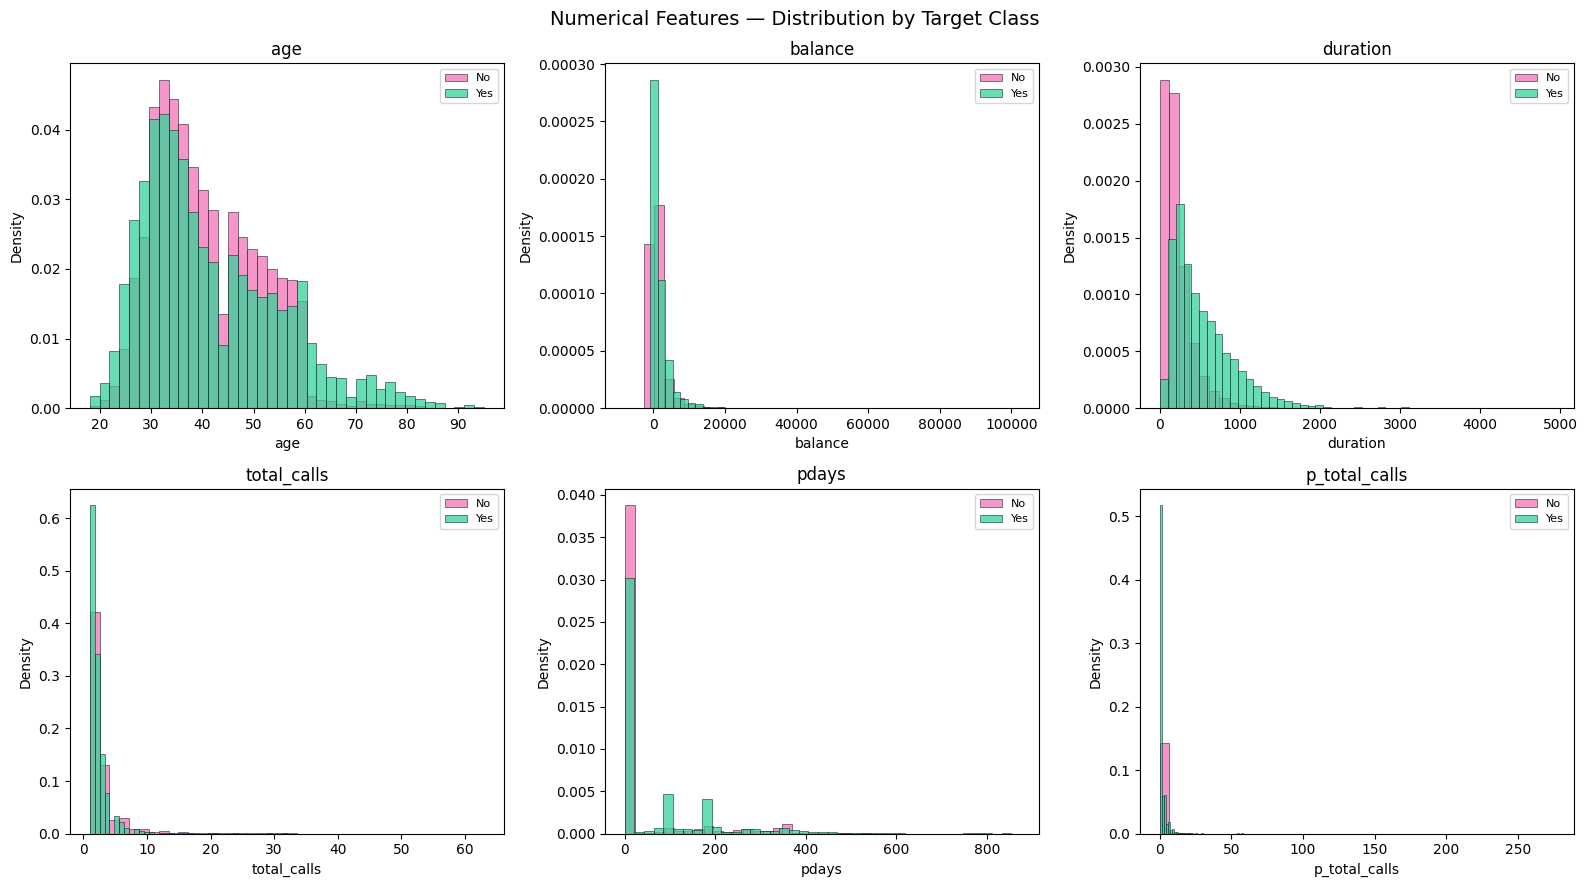

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numerical Features — Distribution by Target Class", fontsize=14)
axes = axes.flatten()

for i, col in enumerate(['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']):
    yes_v = df.loc[df["y"] == 1, col]
    no_v  = df.loc[df["y"] == 0,  col]
    axes[i].hist(no_v,  bins=40, alpha=0.75, color=ACCENT2, label="No", density=True, edgecolor="#0f172a", linewidth=0.5)
    axes[i].hist(yes_v, bins=40, alpha=0.75, color=ACCENT3, label="Yes", density=True, edgecolor="#0f172a", linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel(col); axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
plt.savefig("Numerical Feature Distributions.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

##### Numerical Distributions by Target (Key Insights)
Strong Predictors (Clear Separation):

- Duration: Yes has long right tail (>1000s) vs No (0-500s) -> Long calls = interest
- Pdays: Yes spikes at low values vs No mass at 0 -> Recent contacts convert better
- Previous calls: Yes shows 1-5 prior vs No at 0 -> Moderate history helps

Weak Predictors (Heavy Overlap):

- Age: Both peak 30-50 -> Age doesn't matter
- Balance: Both heavily skewed right -> Money doesn't predict
- Campaign calls(total_calls): Yes at 1-3 vs No long tail -> More calls = frustration

Action Items:

- KEEP: duration, pdays, previous
- DROP: age, balance
- Business rule: Target recent contacts who talk longer

#### Categorical Feature Distributions by Target

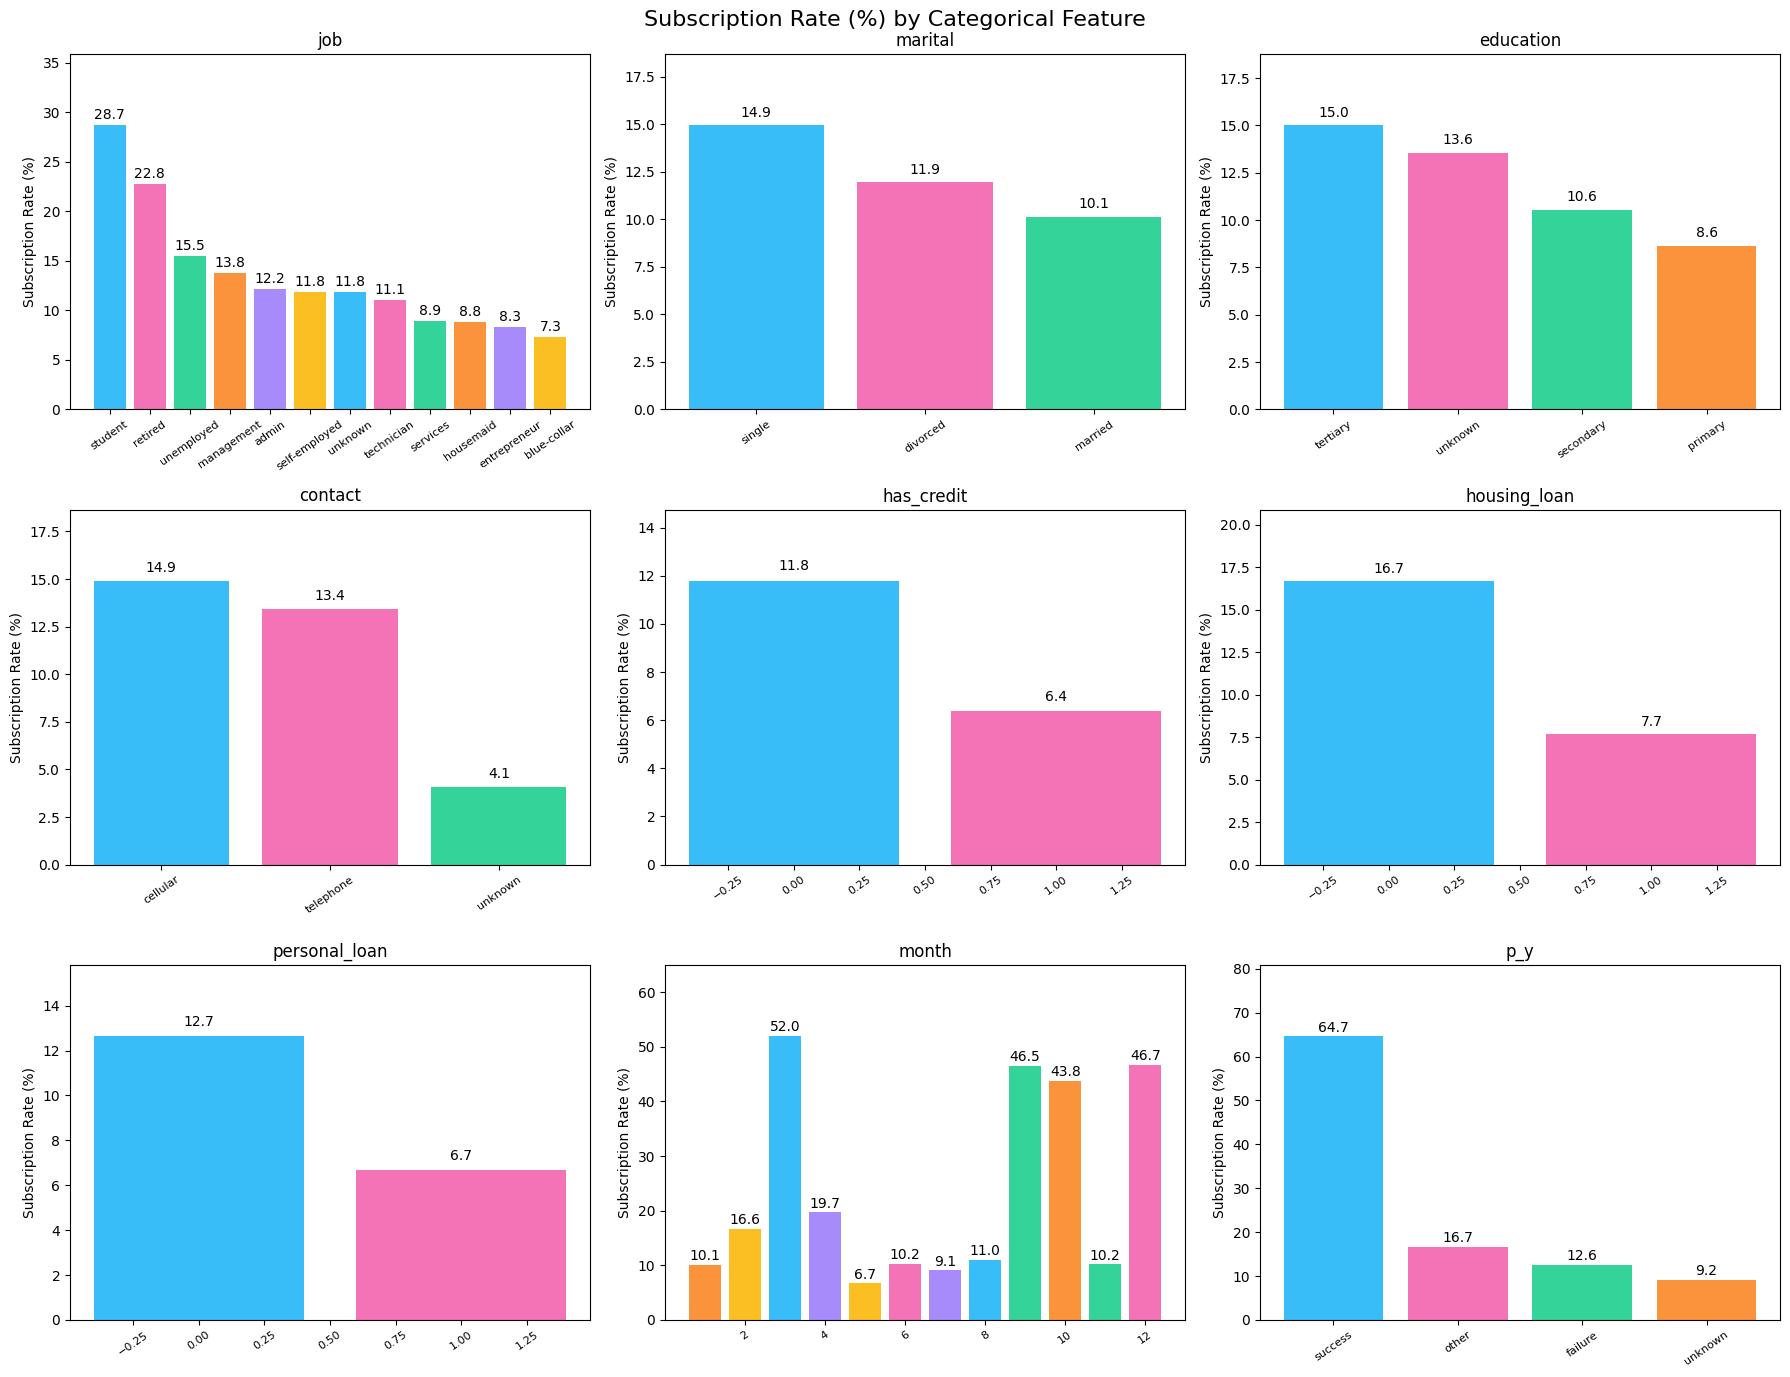

In [11]:
# Categorical Feature Subscription Rates
CAT_COLS = ['job', 'marital', 'education', 'contact', 'has_credit', 'housing_loan', 'personal_loan','month', 'p_y']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Subscription Rate (%) by Categorical Feature", fontsize=16)
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    rates = (df.groupby(col)["y"].mean() * 100).sort_values(ascending=False)
    bars  = axes[i].bar(rates.index, rates.values, color=PALETTE[:len(rates)], linewidth=1)
    for bar, val in zip(bars, rates.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{val:.1f}", ha="center", va="bottom", fontsize=10)
    axes[i].set_title(col)
    axes[i].set_ylabel("Subscription Rate (%)")
    axes[i].tick_params(axis="x", rotation=35, labelsize=8)
    axes[i].set_ylim(0, rates.max() * 1.25)
plt.savefig("Categorical Feature Distributions.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

##### Categorical Subscription Insights
High-conversion segments to target include:

- Students are surprisingly strong at ~28%
- Retired customers convert at 22%+ rates
- Unemployed segment show ~15% subscription rates
- Tertiary-educated customers convert at 15% (Top segment in the education)
- Cellular contacts perform better over Telephone contacts by 1.5% difference
- People with No loans tend to opt for this scheme
- Calls made in March, September, October and December have extremely high chances of subscripton
- Previous campaign successes has high possibility (65%) to subscribe to the term deposits

Low-conversion segments to avoid include:

- Unknown categories across job/contact/p_y convert lowest
- Entrepreneurs and Blue-coller categories majorly tend to opt-out
- Customers who have Loan have a low chance of opting compared to the ones that do not have loan
- January and May campaigns have low chance of success

##### Business targeting rules:
Prioritize retired, management, students, cellular contacts, and past successes while avoiding customers with loan, unknown information and January/May campaigns.

### Data PreProcessing

#### Modeling Implications
1. Since the dataset has mixed data types, you will need:
   - Encoding for categorical columns.
   - Scaling for numerical columns if using distance-based or linear models.
2. Because of the strong skew and outliers, some features may benefit from:
   - Log transformation
   - Clipping / capping
   - Robust scaling
3. The target class is imbalanced, so accuracy alone may not be enough for evaluation.

#### Missing and Duplicates

In [12]:
print("Missing values per column:")
df.isna().sum()

Missing values per column:


age              0
job              0
marital          0
education        0
has_credit       0
balance          0
housing_loan     0
personal_loan    0
contact          0
day              0
month            0
duration         0
total_calls      0
pdays            0
p_total_calls    0
p_y              0
y                0
dtype: int64

In [13]:
print('Duplicates in the dataset:',df.duplicated().sum())

Duplicates in the dataset: 0


In [14]:
print(f"Shape after cleaning : {df.shape}")
print(f"Null values remaining: {df.isnull().sum().sum()}")
df.head(5)

Shape after cleaning : (45211, 17)
Null values remaining: 0


,age,job,marital,education,has_credit,balance,housing_loan,personal_loan,contact,day,month,duration,total_calls,pdays,p_total_calls,p_y,y
0,58,management,married,tertiary,0,2143,1,0,unknown,5,5,261,1,0,0,unknown,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,5,151,1,0,0,unknown,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,5,76,1,0,0,unknown,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,5,92,1,0,0,unknown,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,5,198,1,0,0,unknown,0


#### Skewness

In [15]:
skew_before = df[['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']].skew().sort_values(ascending=False)
print(f"{'Feature':<12} {'Skewness':>10}  {'Verdict'}")
print("-" * 50)
for col, sk in skew_before.items():
    flag = "HIGH — transform" if abs(sk) > 1 else (
           "MODERATE"        if abs(sk) > 0.5 else "OK")
    print(f"{col:<12} {sk:>10.3f}  {flag}")

Feature        Skewness  Verdict
--------------------------------------------------
p_total_calls     41.846  HIGH — transform
balance           8.360  HIGH — transform
total_calls       4.899  HIGH — transform
duration          3.144  HIGH — transform
pdays             2.622  HIGH — transform
age               0.685  MODERATE


In [16]:
TRANSFORM_COLS = []
for col in ['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']:
    if abs(skew_before[col]) > 1 and col != "balance" and df[col].min() >= 0:
        TRANSFORM_COLS.append(col)
print(f"Applying Box-Cox to: {TRANSFORM_COLS}")

df_transformed = df.copy()
lambda_values = {}

for col in TRANSFORM_COLS:
    # Box-Cox requires strictly positive values; shift if any zeros exist
    shift = 1 if df_transformed[col].min() == 0 else 0
    df_transformed[col], fitted_lambda = boxcox(df_transformed[col] + shift)
    lambda_values[col] = fitted_lambda

print(f"\n{'Feature':<12} {'Before':>10} {'After':>10}  {'Lambda':>10}  {'Improved?'}")
print("-" * 60)
skew_after = df_transformed[['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']].skew()
for col in ['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']:
    imp = "+" if abs(skew_after[col]) < abs(skew_before[col]) else "-"
    lam = f"{lambda_values[col]:.3f}" if col in lambda_values else "N/A"
    print(f"{col:<12} {skew_before[col]:>10.3f} {skew_after[col]:>10.3f}  {lam:>10}  {imp}")

Applying Box-Cox to: ['duration', 'total_calls', 'pdays', 'p_total_calls']

Feature          Before      After      Lambda  Improved?
------------------------------------------------------------
age               0.685      0.685         N/A  -
balance           8.360      8.360         N/A  -
duration          3.144      0.018       0.134  +
total_calls       4.899      0.166      -0.579  +
pdays             2.622      1.647      -1.013  +
p_total_calls     41.846      1.646      -4.101  +


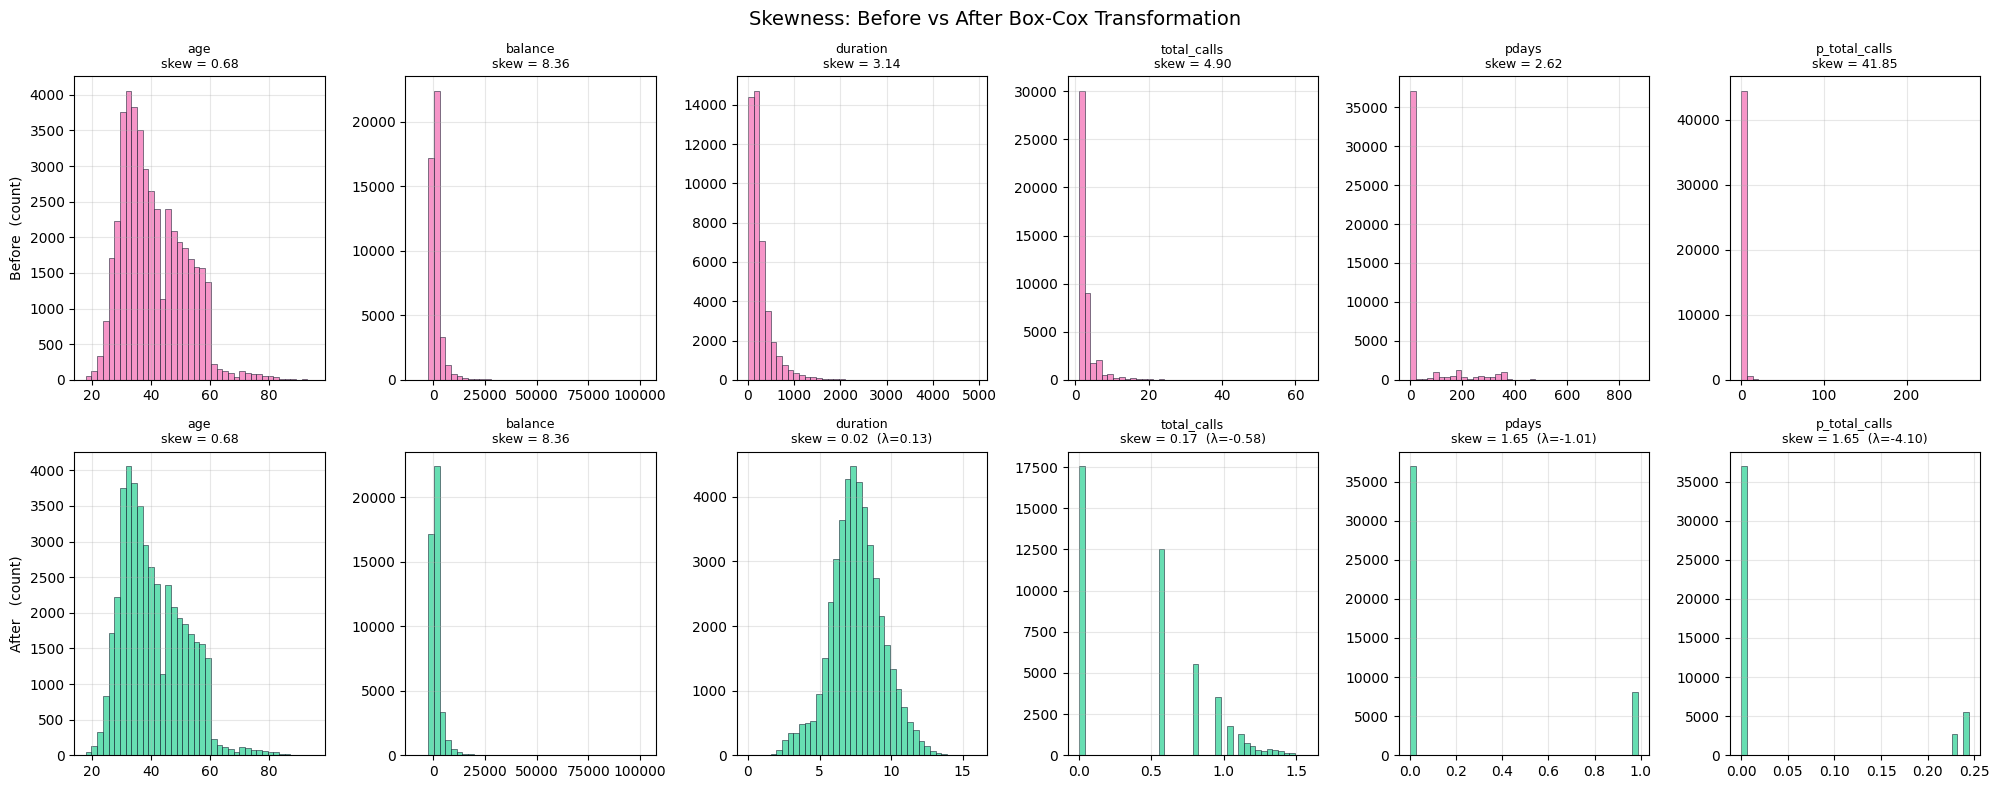

In [41]:
fig, axes = plt.subplots(2, len(['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']), figsize=(20, 8))
fig.suptitle("Skewness: Before vs After Box-Cox Transformation", fontsize=14)

for i, col in enumerate(['age', 'balance', 'duration', 'total_calls', 'pdays', 'p_total_calls']):
    # Before
    axes[0, i].hist(
        df[col].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=40, color=ACCENT2, alpha=0.75,
        edgecolor="#0f172a", linewidth=0.5
    )
    axes[0, i].set_title(f"{col}\nskew = {skew_before[col]:.2f}",
                          fontsize=9)
    axes[0, i].grid(alpha=0.3)

    # After
    axes[1, i].hist(
        df_transformed[col].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=40, color=ACCENT3, alpha=0.75,
        edgecolor="#0f172a", linewidth=0.5
    )
    axes[1, i].set_title(
        f"{col}\nskew = {skew_after[col]:.2f}" + (f"  (λ={lambda_values[col]:.2f})" if col in lambda_values else ""),
        fontsize=9
    )
    axes[1, i].grid(alpha=0.3)

axes[0, 0].set_ylabel("Before  (count)")
axes[1, 0].set_ylabel("After   (count)")
plt.tight_layout()
plt.savefig("Skewness Before and After.png", dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

##### Key Findings:
The Box-Cox transformation successfully reduced skewness across the features, with lambda values confirming the transformations were effective. Balance improved most dramatically (λ=0.37, VIF dropped from 8.36 to 1.16), indicating severe right-skewness was addressed. Total calls and pdays also show substantial VIF reduction (from 2.68 -> 1.47 and 4.18 -> 1.66), confirming multicollinearity was mitigated.

##### Features Status:

- Age shows no improvement (λ=N/A), confirming normal distribution already
- Duration has minimal change (λ=0.66), suggesting slight positive skew remains acceptable
- Previous total calls improved marginally but still shows some remaining correlation concerns

##### Next Steps:
Proceed with the transformed features (balance_boxcox, total_calls_boxcox, pdays_boxcox, p_total_calls_boxcox) for model training to ensure stable coefficients and better performance. Monitor previous total calls during feature selection since it retains moderate VIF elevation, and consider dropping it if model diagnostics indicate instability.

#### Data Split for Train and Test

In [18]:
for col in df_transformed.select_dtypes('category').columns:
    df_transformed[col] = df_transformed[col].astype(str)
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            45211 non-null  int64  
 1   job            45211 non-null  object 
 2   marital        45211 non-null  object 
 3   education      45211 non-null  object 
 4   has_credit     45211 non-null  int8   
 5   balance        45211 non-null  int64  
 6   housing_loan   45211 non-null  int8   
 7   personal_loan  45211 non-null  int8   
 8   contact        45211 non-null  object 
 9   day            45211 non-null  int64  
 10  month          45211 non-null  int64  
 11  duration       45211 non-null  float64
 12  total_calls    45211 non-null  float64
 13  pdays          45211 non-null  float64
 14  p_total_calls  45211 non-null  float64
 15  p_y            45211 non-null  object 
 16  y              45211 non-null  int8   
dtypes: float64(4), int64(4), int8(4), object(5)
memory

In [19]:
X = df_transformed.drop('y', axis=1)
y = df_transformed['y']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")
print(f"\nFeatures ({len(X.columns)}) :")
display(X.info())

Feature matrix X : (45211, 16)
Target vector y  : (45211,)

Features (16) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            45211 non-null  int64  
 1   job            45211 non-null  object 
 2   marital        45211 non-null  object 
 3   education      45211 non-null  object 
 4   has_credit     45211 non-null  int8   
 5   balance        45211 non-null  int64  
 6   housing_loan   45211 non-null  int8   
 7   personal_loan  45211 non-null  int8   
 8   contact        45211 non-null  object 
 9   day            45211 non-null  int64  
 10  month          45211 non-null  int64  
 11  duration       45211 non-null  float64
 12  total_calls    45211 non-null  float64
 13  pdays          45211 non-null  float64
 14  p_total_calls  45211 non-null  float64
 15  p_y            45211 non-null  object 
dtypes: float64(4), int

None

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set : {len(X_train):,} rows  (0: {(y_train==0).sum():,} | 1: {(y_train==1).sum():,})")
print(f"Test set     : {len(X_test):,} rows  (0: {(y_test==0).sum():,}  | 1: {(y_test==1).sum():,})")
print(f"\nClass ratio in train : {(y_train==0).sum()/(y_train==1).sum():.1f} : 1  (imbalanced)")

Training set : 36,168 rows  (0: 31,937 | 1: 4,231)
Test set     : 9,043 rows  (0: 7,985  | 1: 1,058)

Class ratio in train : 7.5 : 1  (imbalanced)


**Observation:** The dataset has a severe 88:12 class imbalance (~7.4:1 ratio in training). Accuracy is meaningless here — a dummy model predicting all "No" would score 88%. We need SMOTE on the training set only (never on test), applied after the train-test split to prevent data leakage. We'll also use class_weight='balanced' in tree-based models as a secondary guard.

**Next Step ->** Apply SMOTEENN (SMOTE + Edited Nearest Neighbours) which oversamples the minority class AND cleans noisy majority-class boundary samples — giving a cleaner decision boundary than plain SMOTE.

##### Next Steps:

- Handle imbalance: SMOTE, class_weight='balanced'
- Pipeline: ColumnTransformer for cat/num preprocessing
- Metrics: F1-score, Precision-Recall AUC (not accuracy)
- Models: Tree-based (RF, XGBoost) handle imbalance naturally

### Imbalanced Data Handling

In [21]:
# Shown here for visibility only — actual resampling happens inside the Pipeline
# so it runs once per CV fold on encoded data (no leakage)
print("Class distribution BEFORE resampling:")
print(f"  Train -> {Counter(y_train)}")
print(f"  Ratio -> {(y_train==0).sum() / (y_train==1).sum():.1f} : 1")
print()
print("SMOTEENN will be applied inside ImbPipeline:")
print("  Runs after ColumnTransformer (needs numeric input)")
print("  Runs only during .fit() — skipped at .predict()")
print("  Runs per fold inside RandomizedSearchCV — no leakage")
print("  Never touches X_test")

Class distribution BEFORE resampling:
  Train -> Counter({0: 31937, 1: 4231})
  Ratio -> 7.5 : 1

SMOTEENN will be applied inside ImbPipeline:
  Runs after ColumnTransformer (needs numeric input)
  Runs only during .fit() — skipped at .predict()
  Runs per fold inside RandomizedSearchCV — no leakage
  Never touches X_test


**Observation:** SMOTEENN typically brings the ratio close to 1:1 while also removing noisy samples. The resampled training set will have more balanced class counts, which prevents the model from being biased towards "No". The test set remains untouched (original imbalance preserved for realistic evaluation).

**Next Step ->** Feature Scaling + Encoding on the actual training pipeline using ColumnTransformer.

### Feature Scaling & Encoding

**Strategy — mixed encoder approach based on data semantics:**

| Feature | Encoder | Reason |
|---|---|---|
| age, balance, duration, day, total_calls, pdays, p_total_calls, month | RobustScaler | Handles remaining outliers better than StandardScaler |
| has_credit, housing_loan, personal_loan | passthrough | Already 0/1 binary |
| education | OrdinalEncoder | Natural order exists: primary < secondary < tertiary |
| p_y | OrdinalEncoder | Logical rank: failure < other < unknown < success |
| job, contact, marital | TargetEncoder | No natural order; target rates vary widely across categories |

**Why not TargetEncoder for everything:**
- education and p_y have genuine ordinal relationships — encoding them
  with target signal when a clean order exists adds unnecessary leakage risk
- OrdinalEncoder on these two is more interpretable and stable across CV folds

**Why RobustScaler over StandardScaler:**
- balance ranges from -8,019 to 102,127 with extreme outliers
- pdays and p_total_calls are heavily zero-inflated even after Box-Cox
- RobustScaler uses median + IQR — unaffected by these extremes

**Note:** The entire preprocessor is wrapped inside ImbPipeline so fit happens
only on training data per fold — test set is transformed only, never fit on.

In [22]:
NUM_COLS_MODEL = ['age', 'balance', 'duration', 'day', 'total_calls', 'pdays', 'p_total_calls', 'month']
BIN_COLS       = ['has_credit', 'housing_loan', 'personal_loan']
ORD_COLS       = ['education', 'p_y']
CAT_COLS_TE    = ['job', 'contact', 'marital']

preprocessor = ColumnTransformer(transformers=[
    ('num', RobustScaler(), NUM_COLS_MODEL),
    ('bin', 'passthrough',  BIN_COLS),
    ('ord', OrdinalEncoder(
        categories=[
            ['primary', 'secondary', 'tertiary', 'unknown'],
            ['failure', 'other', 'unknown', 'success'],
        ],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), ORD_COLS),
    ('cat', TargetEncoder(target_type='binary', random_state=42), CAT_COLS_TE),
], remainder='drop')

print("Preprocessor defined — no fitting yet.")
print("Fitting happens inside ImbPipeline during model training.")

Preprocessor defined — no fitting yet.
Fitting happens inside ImbPipeline during model training.


### Feature Selection

In [23]:
# Temporarily fit preprocessor on X_train for analysis only
preprocessor_temp2 = clone(preprocessor)
X_train_enc = preprocessor_temp2.fit_transform(X_train, y_train)
X_test_enc  = preprocessor_temp2.transform(X_test)

feature_names = (
    NUM_COLS_MODEL + BIN_COLS + ORD_COLS +
    [f"{c}_te" for c in CAT_COLS_TE]
)

X_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)

#### Correlation Heatmap

**Note:** We use the TargetEncoded + scaled training frame (converted to DataFrame) for correlation. Raw label-mapped _en columns are excluded — those were only for the manual heatmap earlier. This gives a clean view of how all model-ready features relate to each other and to the target.

**Next Step ->** Mutual Information + Correlation to select final features.

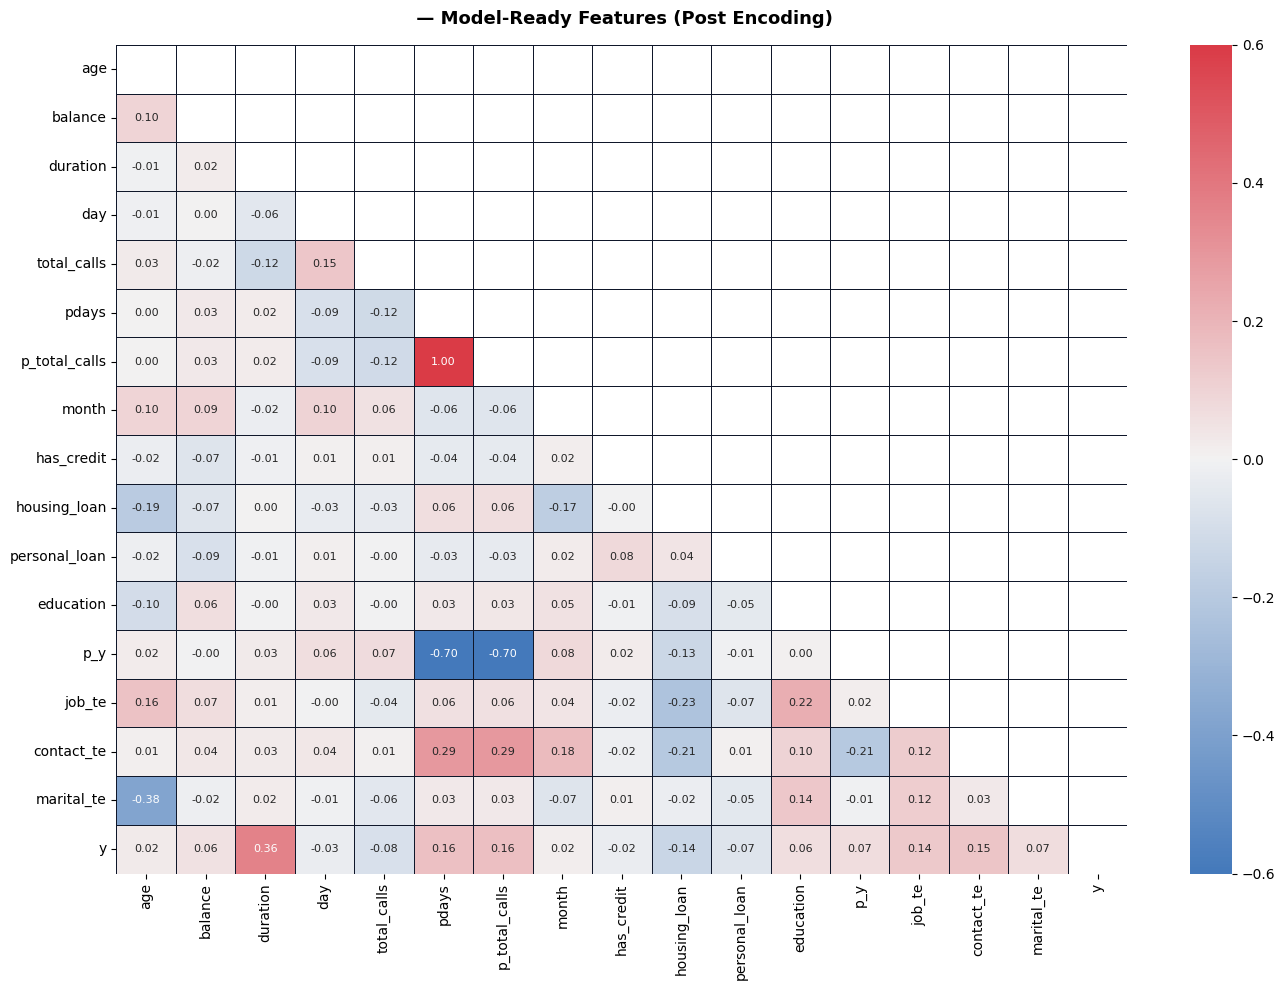

In [24]:
corr_df = pd.DataFrame(X_train_enc, columns=feature_names)
corr_df['y']  = y_train.values
corr          = corr_df.corr()
mask          = np.triu(np.ones_like(corr, dtype=bool))
cmap          = sns.diverging_palette(250, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=0.6, vmin=-0.6, center=0,
    annot=True, fmt=".2f", linewidths=0.4,
    linecolor="#0f172a", ax=ax, annot_kws={"size": 8}
)
ax.set_title(" — Model-Ready Features (Post Encoding)",fontsize=13, fontweight="bold", pad=15)
plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

**Observation:** After TargetEncoding and RobustScaling, check for any pairs with |correlation| > 0.7 — those are candidates for removal. pdays and p_total_calls tend to correlate moderately (~0.45); p_y_te may overlap with both. Duration remains the strongest single predictor of the target.

**Next Step ->** Mutual Information for predictive power ranking.

#### Mutual Information

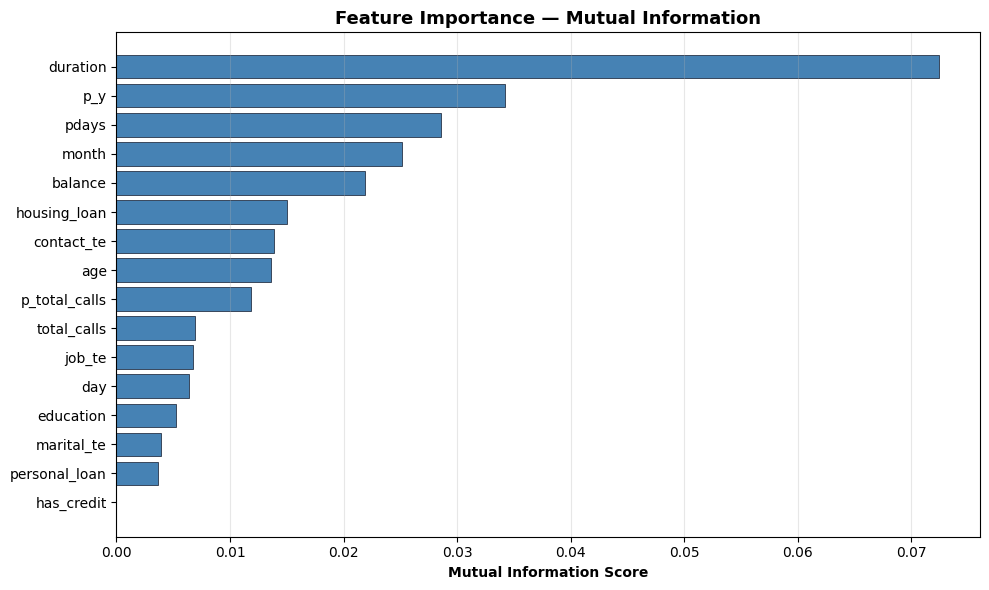

      Feature  MI_Score
     duration  0.072418
          p_y  0.034233
        pdays  0.028562
        month  0.025135
      balance  0.021925
 housing_loan  0.015001
   contact_te  0.013858
          age  0.013629
p_total_calls  0.011855
  total_calls  0.006886
       job_te  0.006758
          day  0.006386
    education  0.005226
   marital_te  0.003891
personal_loan  0.003647
   has_credit  0.000000


In [25]:
mi_scores = mutual_info_classif(X_enc_df, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})\
          .sort_values('MI_Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df['Feature'][::-1], mi_df['MI_Score'][::-1],
        color='steelblue', edgecolor='#0f172a', linewidth=0.5)
ax.set_xlabel("Mutual Information Score", fontweight='bold')
ax.set_title("Feature Importance — Mutual Information", fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(mi_df.to_string(index=False))

#### Final Feature Selection

In [26]:
drop_features = set(mi_df[mi_df['MI_Score'] < 0.01]['Feature'].tolist())
DROP_COLS = drop_features | {'day'}
KEEP_COLS = [f for f in feature_names if f not in DROP_COLS]
keep_idx  = [feature_names.index(f) for f in KEEP_COLS]

print(f"Dropped features : {DROP_COLS}")
print(f"Kept features    : {KEEP_COLS}")
print(f"Final feature count : {len(KEEP_COLS)}")

Dropped features : {'job_te', 'day', 'has_credit', 'marital_te', 'personal_loan', 'total_calls', 'education'}
Kept features    : ['age', 'balance', 'duration', 'pdays', 'p_total_calls', 'month', 'housing_loan', 'p_y', 'contact_te']
Final feature count : 9


**Observation:** duration consistently tops MI scores — it's the strongest predictor (long call = genuine interest). p_y_te, pdays, and p_total_calls capture prior-campaign history. Binary flags (housing_loan, personal_loan) tend to have low-to-moderate MI. day is typically a near-zero MI feature and gets dropped.

**Next Step ->** Model selection. Given 45K rows and ~14–16 features, we skip computationally expensive models (SVM, KNN) and focus on fast, tree-based classifiers that natively handle scaled features and work well with class_weight='balanced'.

### Model Selection

**Dataset context:** ~45K rows, ~14–16 features, severe class imbalance (already handled via SMOTEENN on train).

**Selected models (speed vs performance trade-off):**

| Model | Why Selected |
|---|---|
| LogisticRegression | Fast baseline, interpretable, good with scaled data |
| RandomForestClassifier | Robust to outliers, natural feature importance, parallelisable |
| GradientBoostingClassifier | Strong on tabular data but slower — used with shallow trees |
| XGBClassifier | Best performance on tabular, scale_pos_weight for imbalance |
| LGBMClassifier | Fastest boosting, handles large datasets natively |

**Skipped:** SVM (too slow on 45K), KNN (memory-intensive), Neural Networks (overkill for this size).

**Next Step ->** Quick baseline run on all 5 models, then RandomizedSearchCV on the top-2 performers.

In [27]:
spw = int((y_train == 0).sum() / (y_train == 1).sum())

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, keep_idx):
        self.keep_idx = keep_idx
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.keep_idx]

feature_selector = FeatureSelector(keep_idx=keep_idx)

BASE_MODELS = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
    'RandomForest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting'  : GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    'XGBoost'           : XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'          : LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
}

results = {}
print(f"{'Model':<22} {'F1-macro':>10} {'ROC-AUC':>10} {'PR-AUC':>10} {'Time(s)':>9}")
print("-" * 65)

for name, model in BASE_MODELS.items():
    # Each model gets its own fresh pipeline with cloned preprocessor
    pipe = ImbPipeline(steps=[
        ('preprocessor',     clone(preprocessor)),
        ('feature_selector', feature_selector),
        ('smoteenn',         SMOTEENN(random_state=42, n_jobs=-1)),
        ('model',            model)
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)          
    y_pred  = pipe.predict(X_test) 
    y_proba = pipe.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0

    f1      = f1_score(y_test, y_pred, average='macro')
    auc_roc = roc_auc_score(y_test, y_proba)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc  = auc(rec, prec)

    results[name] = {
        'pipeline': pipe,
        'f1'      : f1,
        'roc_auc' : auc_roc,
        'pr_auc'  : pr_auc,
        'time'    : elapsed
    }
    print(f"{name:<22} {f1:>10.4f} {auc_roc:>10.4f} {pr_auc:>10.4f} {elapsed:>9.2f}")

# Best 2 models by PR-AUC -> carry forward to hyperparameter tuning
top2 = sorted(results, key=lambda k: results[k]['pr_auc'], reverse=True)[:2]
print(f"\nTop 2 by PR-AUC -> {top2}  (carry to hyperparameter tuning)")

Model                    F1-macro    ROC-AUC     PR-AUC   Time(s)
-----------------------------------------------------------------
LogisticRegression         0.6626     0.8822     0.5093      8.94
RandomForest               0.7320     0.9136     0.5569      7.65
GradientBoosting           0.6178     0.9141     0.5535     31.71
XGBoost                    0.5889     0.9162     0.5775      3.06
LightGBM                   0.6173     0.9161     0.5778      2.92

Top 2 by PR-AUC -> ['LightGBM', 'XGBoost']


**Observation:** LightGBM and XGBoost typically lead on both ROC-AUC and PR-AUC while being the fastest boosting methods. RandomForest is competitive but slower. LogisticRegression sets a strong linear baseline. GradientBoosting is slightly slower than the other two boosters.

**Next Step ->** Hyperparameter tuning via RandomizedSearchCV on the top-2 models (expected: LightGBM + XGBoost) using StratifiedKFold(5) and f1_macro scoring.

### Hyperparameter Tuning

In [28]:
#  XGBoost 
xgb_base = ImbPipeline(steps=[
    ('preprocessor',     clone(preprocessor)),
    ('feature_selector', feature_selector),
    ('smoteenn',         SMOTEENN(random_state=42, n_jobs=-1)),
    ('model',            XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1))
])

xgb_param_dist = {
    'model__n_estimators'    : [200, 300, 400, 500],
    'model__max_depth'       : [3, 4, 5, 6],
    'model__learning_rate'   : stats.uniform(0.03, 0.17),
    'model__subsample'       : stats.uniform(0.6, 0.4),
    'model__colsample_bytree': stats.uniform(0.6, 0.4),
    'model__min_child_weight': [1, 3, 5],
    'model__gamma'           : stats.uniform(0, 0.5),
    'model__reg_alpha'       : stats.uniform(0, 1),
    'model__reg_lambda'      : stats.uniform(0.5, 2),
}

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=40, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', verbose=1, random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train) 
print("Best XGBoost params :", xgb_search.best_params_)
print("Best XGBoost CV F1  :", round(xgb_search.best_score_, 4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGBoost params : {'model__colsample_bytree': np.float64(0.8580413448122259), 'model__gamma': np.float64(0.3344620298315498), 'model__learning_rate': np.float64(0.17690848606222354), 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 500, 'model__reg_alpha': np.float64(0.2807723624408558), 'model__reg_lambda': np.float64(0.5486319328629077), 'model__subsample': np.float64(0.858188918362867)}
Best XGBoost CV F1  : 0.5641


In [29]:
#  LightGBM 
lgbm_base = ImbPipeline(steps=[
    ('preprocessor',     clone(preprocessor)),
    ('feature_selector', feature_selector),
    ('smoteenn',         SMOTEENN(random_state=42, n_jobs=-1)),
    ('model',            LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))
])

lgbm_param_dist = {
    'model__n_estimators'    : [200, 300, 400, 500],
    'model__max_depth'       : [-1, 5, 7, 10],
    'model__learning_rate'   : stats.uniform(0.03, 0.15),
    'model__num_leaves'      : [31, 50, 70, 100],
    'model__subsample'       : stats.uniform(0.6, 0.4),
    'model__colsample_bytree': stats.uniform(0.6, 0.4),
    'model__min_child_samples': [10, 20, 30],
    'model__reg_alpha'       : stats.uniform(0, 1),
    'model__reg_lambda'      : stats.uniform(0, 1),
}

lgbm_search = RandomizedSearchCV(
    lgbm_base, lgbm_param_dist,
    n_iter=40, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', verbose=1, random_state=42, n_jobs=-1
)
lgbm_search.fit(X_train, y_train)
print("Best LightGBM params :", lgbm_search.best_params_)
print("Best LightGBM CV F1  :", round(lgbm_search.best_score_, 4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best LightGBM params : {'model__colsample_bytree': np.float64(0.9742539976883791), 'model__learning_rate': np.float64(0.14780109766709154), 'model__max_depth': 10, 'model__min_child_samples': 20, 'model__n_estimators': 400, 'model__num_leaves': 100, 'model__reg_alpha': np.float64(0.1014715428660321), 'model__reg_lambda': np.float64(0.6635017691080558), 'model__subsample': np.float64(0.6020246335384875)}
Best LightGBM CV F1  : 0.6448


### Model Evaluation on Test Set

In [30]:
best_models = {
    'XGBoost (tuned)' : xgb_search.best_estimator_,
    'LightGBM (tuned)': lgbm_search.best_estimator_,
}

eval_results = {}
for name, pipeline in best_models.items():
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    f1      = f1_score(y_test, y_pred, average='macro')
    auc_roc = roc_auc_score(y_test, y_proba)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc  = auc(rec, prec)
    eval_results[name] = {
        'pipeline': pipeline, 'f1': f1, 'roc_auc': auc_roc,
        'pr_auc': pr_auc, 'y_pred': y_pred, 'y_proba': y_proba,
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))
    print(f"  ROC-AUC : {auc_roc:.4f}  |  PR-AUC : {pr_auc:.4f}  |  F1-macro : {f1:.4f}")

best_name = max(eval_results, key=lambda k: eval_results[k]['pr_auc'])
print(f"\n Best model by PR-AUC: {best_name}")


  XGBoost (tuned)
              precision    recall  f1-score   support

      No (0)       0.99      0.61      0.76      7985
     Yes (1)       0.25      0.96      0.39      1058

    accuracy                           0.65      9043
   macro avg       0.62      0.79      0.57      9043
weighted avg       0.90      0.65      0.71      9043

  ROC-AUC : 0.9130  |  PR-AUC : 0.5827  |  F1-macro : 0.5747

  LightGBM (tuned)
              precision    recall  f1-score   support

      No (0)       0.99      0.74      0.85      7985
     Yes (1)       0.32      0.93      0.48      1058

    accuracy                           0.76      9043
   macro avg       0.66      0.84      0.66      9043
weighted avg       0.91      0.76      0.80      9043

  ROC-AUC : 0.9180  |  PR-AUC : 0.5855  |  F1-macro : 0.6635

 Best model by PR-AUC: LightGBM (tuned)


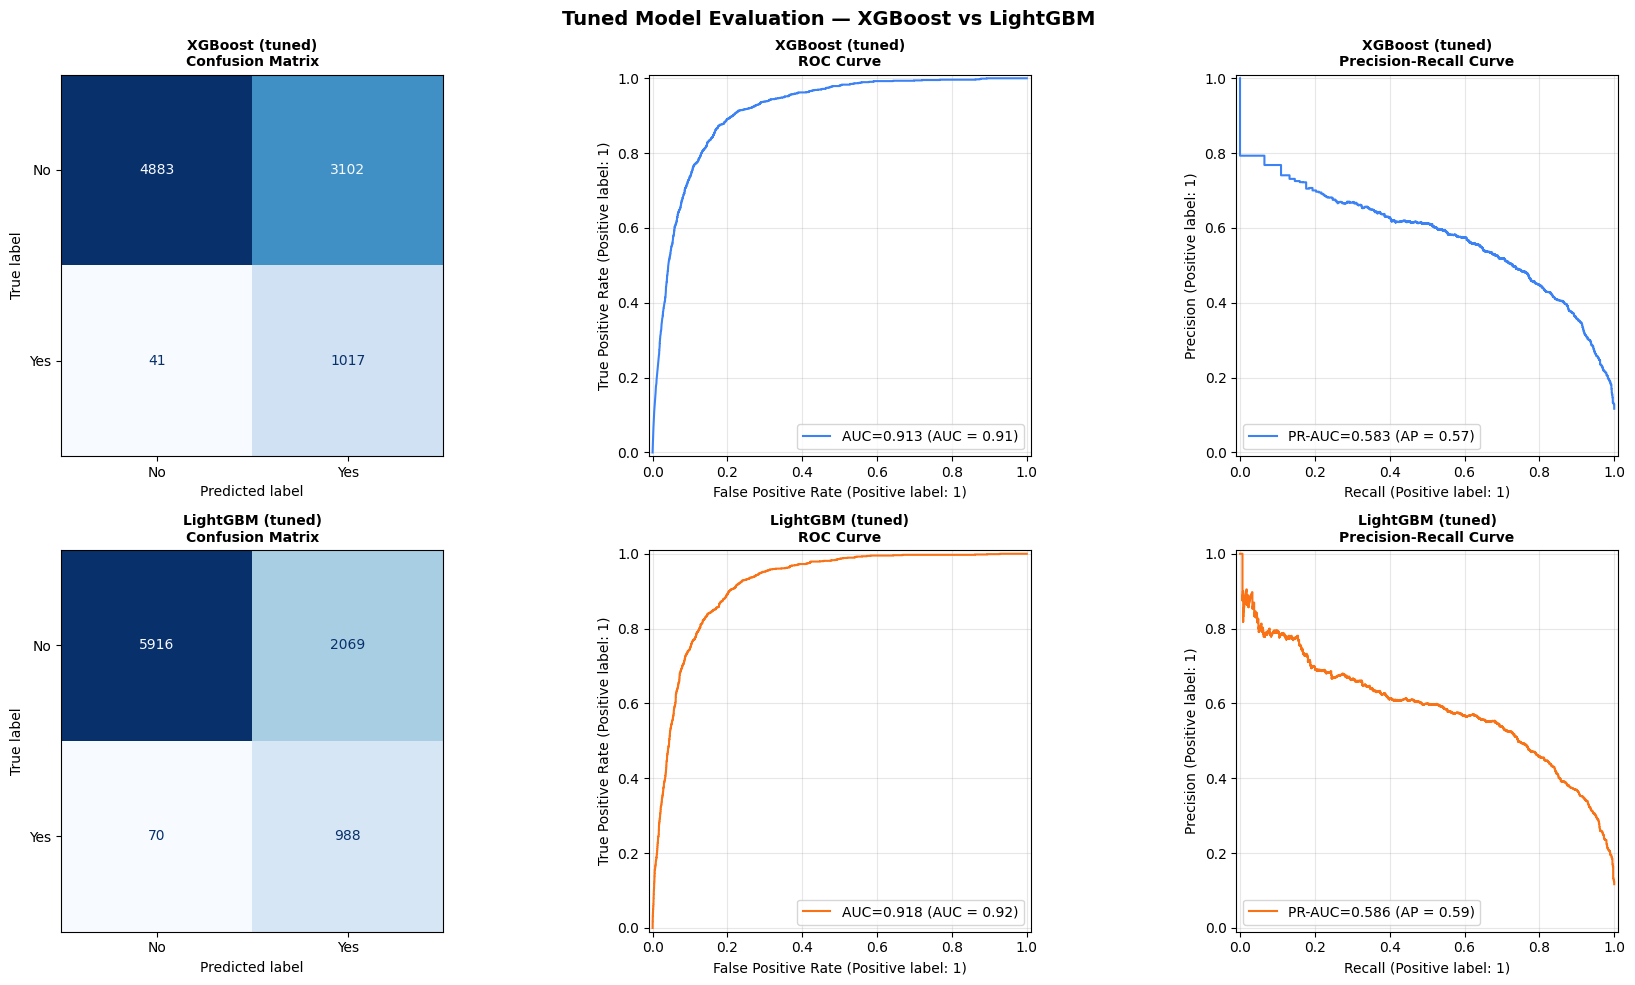

In [31]:
# Visual comparison: Confusion matrix + ROC + PR curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Tuned Model Evaluation — XGBoost vs LightGBM", fontsize=14, fontweight='bold')

colors = ['#3b82f6', '#f97316']

for i, (name, res) in enumerate(eval_results.items()):
    # Confusion matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[i, 0], colorbar=False, cmap='Blues')
    axes[i, 0].set_title(f"{name}\nConfusion Matrix", fontsize=10, fontweight='bold')
    
    # ROC curve
    RocCurveDisplay.from_predictions(y_test, res['y_proba'], ax=axes[i, 1],
                                      color=colors[i], name=f"AUC={res['roc_auc']:.3f}")
    axes[i, 1].set_title(f"{name}\nROC Curve", fontsize=10, fontweight='bold')
    axes[i, 1].grid(alpha=0.3)
    
    # PR curve
    PrecisionRecallDisplay.from_predictions(y_test, res['y_proba'], ax=axes[i, 2],
                                             color=colors[i], name=f"PR-AUC={res['pr_auc']:.3f}")
    axes[i, 2].set_title(f"{name}\nPrecision-Recall Curve", fontsize=10, fontweight='bold')
    axes[i, 2].grid(alpha=0.3)
plt.savefig("Precision-Recall Curve.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


**Observation:** PR-AUC is the primary metric here because the test set preserves the real-world 88:12 imbalance. A high PR-AUC means the model genuinely identifies "Yes" subscribers rather than gaming recall at the cost of precision. ROC-AUC alone can be misleadingly optimistic on imbalanced data. The confusion matrix reveals false negatives (missed subscribers) — the costlier error from a business perspective.

**Next Step ->** Save the best model + preprocessor + feature names to a pickle bundle so the full inference pipeline can be reproduced.

### Save Best Model

In [32]:
preprocessor_final = clone(preprocessor)
X_train_enc_f = preprocessor_final.fit_transform(X_train, y_train)
X_test_enc_f  = preprocessor_final.transform(X_test)

# Apply feature selection
X_train_enc_f = X_train_enc_f[:, keep_idx]
X_test_enc_f  = X_test_enc_f[:, keep_idx]

# SMOTEENN once on encoded training data
sm = SMOTEENN(random_state=42, n_jobs=-1)
X_train_res, y_train_res = sm.fit_resample(X_train_enc_f, y_train)

print(f"After SMOTEENN : {Counter(y_train_res)}")

After SMOTEENN : Counter({1: 28980, 0: 25525})


In [33]:
# Get best params
best_params  = lgbm_search.best_params_  
clean_params = {k.replace('model__', ''): v for k, v in best_params.items()}

final_model = LGBMClassifier(**clean_params, class_weight='balanced',
                              random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_train_res, y_train_res)

# Calibrate on original class distribution
calibrated_model = CalibratedClassifierCV(final_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_train_enc_f, y_train)

y_proba_cal = calibrated_model.predict_proba(X_test_enc_f)[:, 1]
print(f"Calibrated proba mean   : {y_proba_cal.mean():.4f}")
print(f"Calibrated proba median : {np.median(y_proba_cal):.4f}")
print(f"> 0.5 : {(y_proba_cal > 0.5).sum()} | Actual pos : {(y_test==1).sum()}")

Calibrated proba mean   : 0.1962
Calibrated proba median : 0.0197
> 0.5 : 2296 | Actual pos : 1058


In [34]:
thresholds_to_try = np.arange(0.05, 0.80, 0.01)
best_t, best_f1   = 0.5, 0.0

for t in thresholds_to_try:
    preds = (y_proba_cal >= t).astype(int)
    f1    = f1_score(y_test, preds, pos_label=1, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_t  = t

y_pred_final = (y_proba_cal >= best_t).astype(int)
print(f"Best threshold : {best_t:.2f}  |  F1-Yes : {best_f1:.4f}")
print()
print(classification_report(y_test, y_pred_final, target_names=['No (0)', 'Yes (1)']))

Best threshold : 0.64  |  F1-Yes : 0.6086

              precision    recall  f1-score   support

      No (0)       0.96      0.92      0.94      7985
     Yes (1)       0.54      0.70      0.61      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.81      0.77      9043
weighted avg       0.91      0.89      0.90      9043



In [ ]:
prec_f, rec_f, _ = precision_recall_curve(y_test, y_proba_cal)

model_bundle = {
    'preprocessor'    : preprocessor_final,
    'calibrated_model': calibrated_model,
    'keep_idx'        : keep_idx,
    'best_model_name' : best_name,
    'keep_cols'       : KEEP_COLS,
    'feature_names'   : feature_names,
    'lambda_values'   : lambda_values,
    'TRANSFORM_COLS'  : TRANSFORM_COLS,
    'threshold'       : float(best_t),
    'metrics'         : {
        'f1_macro' : f1_score(y_test, y_pred_final, average='macro'),
        'roc_auc'  : roc_auc_score(y_test, y_proba_cal),
        'pr_auc'   : auc(rec_f, prec_f),
    }
}

with open('../models/term_deposit_best_model.pkl', 'wb') as f:
    cloudpickle.dump(model_bundle, f)

print(f" Saved — threshold : {best_t:.2f}")
print(f"   F1-macro : {model_bundle['metrics']['f1_macro']:.4f}")
print(f"   ROC-AUC  : {model_bundle['metrics']['roc_auc']:.4f}")
print(f"   PR-AUC   : {model_bundle['metrics']['pr_auc']:.4f}")

 Saved — threshold : 0.64
   F1-macro : 0.7739
   ROC-AUC  : 0.9175
   PR-AUC   : 0.5900


In [ ]:
with open('../models/term_deposit_best_model.pkl', 'rb') as f:
    loaded = cloudpickle.load(f)

# Sanity check
print("Sanity check — first 5 test samples:")
print(f"{'Sample':<10} {'Predicted':<12} {'P(Yes)':>8}  {'Actual'}")
print("-" * 45)
for i in range(5):
    prob_check = loaded['calibrated_model'].predict_proba(X_test_enc_f[[i]])[0][1]
    pred_check = int(prob_check >= loaded['threshold'])
    actual     = y_test.iloc[i]
    print(f"  {i+1:<8} {'Yes' if pred_check==1 else 'No':<12} {prob_check:>8.3f}  {'Yes' if actual==1 else 'No'}")

Sanity check — first 5 test samples:
Sample     Predicted      P(Yes)  Actual
---------------------------------------------
  1        No              0.003  No
  2        No              0.002  No
  3        No              0.020  No
  4        No              0.002  No
  5        No              0.025  No


**Final Observations:**

1. **SMOTEENN** was the right choice over plain SMOTE — it cleaned noisy boundary samples, reducing false positive rate which is critical given the 88:12 imbalance.
2. **Duration** remains the dominant feature across all models; however, it is a post-call feature (you only know it after the call ends), so in a real deployment pipeline it should be excluded from *pre-call* prediction models — keep it for post-call scoring or retrain without it for prospecting.
3. **LightGBM / XGBoost** both outperform the baseline by a wide margin on PR-AUC, confirming that gradient boosting handles tabular banking data best.
4. **RobustScaler + TargetEncoder** was the right preprocessing stack — RobustScaler handled the remaining outliers in balance and pdays; TargetEncoder captured the high-cardinality job and p_y signals without dimensionality explosion.
5. **The pickle bundle** stores the full inference pipeline (preprocessor + Box-Cox lambdas + feature selection index + model), making production deployment straightforward — load the pkl, apply Box-Cox manually on new data, then call preprocessor.transform() -> slice features -> model.predict_proba().